# Early Exit Extension for BERT-Tiny

This notebook extends the Early Exit implementation for `BERT-Tiny` with additional features:
- **Entropy-based Exit Criteria**: Replaces or supplements standard probability thresholds with Shannon entropy for more robust exit decisions.
- **Head-specific Finetuning**: Independently trains intermediate classifier heads to improve their prediction accuracy.
- **Dynamic Threshold Selection**: Implements a search routine to select optimal per-head thresholds under specific latency constraints.
- **Performance Profiling**: Visualizes the accuracy-latency Pareto front before and after head finetuning.


In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    default_data_collator
)
from torch.utils.data import DataLoader
from datasets import load_dataset
from chop import MaseGraph
from chop.tools import get_tokenized_dataset


/home/dt822/adls/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/dt822/adls/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    props = torch.cuda.get_device_properties(0)
    print("Using CUDA device:", props.name)
else:
    DEVICE = torch.device("cpu")
    print("CUDA not available — using CPU")

CHECKPOINT = "DeepWokLab/bert-tiny"
DATASET_NAME = "imdb"

dataset, tokenizer = get_tokenized_dataset(
    dataset=DATASET_NAME,
    checkpoint=CHECKPOINT,
    return_tokenizer=True,
)

# Prepare Splits
eval_ds = dataset["test"].remove_columns(["text", "token_type_ids"]).rename_column("label", "labels")
train_ds = dataset["train"].remove_columns(["text", "token_type_ids"]).rename_column("label", "labels")
split_ds = eval_ds.train_test_split(test_size=0.5, seed=42)

val_ds = split_ds["train"]
test_ds = split_ds["test"]

train_dataloader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=DataCollatorWithPadding(tokenizer))
test_dataloader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=DataCollatorWithPadding(tokenizer))
val_dataloader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=DataCollatorWithPadding(tokenizer))


INFO     Tokenizing dataset imdb with AutoTokenizer for DeepWokLab/bert-tiny.


Using CUDA device: NVIDIA RTX A6000


In [ ]:
@torch.no_grad()
def eval_accuracy(model, dataloader, device="cuda"):
    model.eval()
    correct, total = 0, 0
    for batch in tqdm(dataloader, desc="Eval Accuracy", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        logits = out["logits"] if isinstance(out, dict) else out.logits
        correct += (logits.argmax(dim=-1) == batch["labels"]).sum().item()
        total += batch["labels"].size(0)
    acc = correct / total
    print(f"Accuracy: {acc * 100:.2f}% ({correct}/{total})")
    return acc

@torch.no_grad()
def eval_accuracy_head(model, dataloader, device="cuda", head_idx=0):
    model.eval()
    correct, total = 0, 0
    for batch in tqdm(dataloader, desc=f"Eval Head {head_idx}", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model.forward_no_exit_criteria(**batch, head_idx=head_idx)
        logits = out["logits"] if isinstance(out, dict) else out.logits
        correct += (logits.argmax(dim=-1) == batch["labels"]).sum().item()
        total += batch["labels"].size(0)
    acc = correct / total
    print(f"Head {head_idx} Accuracy: {acc * 100:.2f}% ({correct}/{total})")
    return acc

@torch.no_grad()
def eval_speed(model, dataloader, device="cuda", num_batches=100, warmup=10):
    model.eval()
    if isinstance(device, str):
        device = torch.device(device)
    
    batches = list(dataloader)[:warmup + num_batches]
    for b in batches[:warmup]:
        model(**{k: v.to(device) for k, v in b.items()})
    
    if device.type == "cuda":
        torch.cuda.synchronize()

    times, samples = [], 0
    for b in batches[warmup:]:
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(**{k: v.to(device) for k, v in b.items()})
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
        samples += b["input_ids"].size(0)
    
    total_time = sum(times)
    avg_per_batch_ms = np.mean(times) * 1000
    avg_per_sample_ms = (total_time / samples) * 1000
    print(f"Throughput: {samples / total_time:.1f} samples/sec | Latency: {avg_per_sample_ms:.2f} ms/sample")
    return [avg_per_batch_ms, avg_per_sample_ms]


Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 12500
})
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 12500
})
val_ds size: 12500


In [ ]:
class EarlyExitBert(nn.Module):
    def __init__(self, original_model, threshold=0.9):
        super().__init__()
        self.bert = original_model.bert
        self.encoder_layers = nn.ModuleList(list(self.bert.encoder.layer.children()))
        self.num_layers = len(self.encoder_layers)
        self.classifier_heads = nn.ModuleList([copy.deepcopy(original_model.classifier) for _ in range(self.num_layers)])
        self.classifier_head = original_model.classifier
        self.classifier_thresholds = [threshold for _ in range(self.num_layers)]
        self.classifier_threshold = threshold

    def forward(self, input_ids, attention_mask, labels=None):
        device = input_ids.device
        batch_size = input_ids.size(0)
        extended_attention_mask = self.bert.get_extended_attention_mask(attention_mask, input_ids.size(), device)
        hidden_states = self.bert.embeddings(input_ids=input_ids)
        
        final_logits = torch.zeros(batch_size, self.classifier_head.out_features, device=device)
        active_mask = extended_attention_mask
        active_indices = torch.arange(batch_size, device=device)

        for i, layer_module in enumerate(self.encoder_layers):
            layer_outputs = layer_module(hidden_states, attention_mask=active_mask)
            hidden_states = layer_outputs[0]
            pooled_output = self.bert.pooler(hidden_states)
            logits = self.classifier_head(pooled_output)
            
            if i == self.num_layers - 1:
                final_logits[active_indices] = logits
                break

            probs = F.softmax(logits, dim=-1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1)
            confident = entropy <= self.classifier_threshold
            
            final_logits[active_indices[confident]] = logits[confident]
            not_confident = ~confident
            if not not_confident.any():
                break
            
            active_indices = active_indices[not_confident]
            hidden_states = hidden_states[not_confident]
            active_mask = active_mask[not_confident]
        
        return {"logits": final_logits}

    def forward_no_exit_criteria(self, input_ids, attention_mask, labels=None, head_idx=-1):
        if head_idx == -1:
            head_idx = self.num_layers - 1
        device = input_ids.device
        batch_size = input_ids.size(0)
        extended_attention_mask = self.bert.get_extended_attention_mask(attention_mask, input_ids.size(), device)
        hidden_states = self.bert.embeddings(input_ids=input_ids)
        active_mask = extended_attention_mask

        for i, layer_module in enumerate(self.encoder_layers):
            if i > head_idx:
                break
            layer_outputs = layer_module(hidden_states, attention_mask=active_mask)
            hidden_states = layer_outputs[0]
            
        pooled_output = self.bert.pooler(hidden_states)
        final_logits = self.classifier_head(pooled_output)
        return {"logits": final_logits}

    def finetune_classifier_head(self, head_idx, train_dataloader, device):
        for param in self.bert.parameters():
            param.requires_grad = False
        for i, classifier_head in enumerate(self.classifier_heads):
            for param in classifier_head.parameters():
                param.requires_grad = (i == head_idx)

        optimizer = torch.optim.Adam(self.classifier_heads[head_idx].parameters(), lr=1e-4)
        loss_fn = nn.CrossEntropyLoss()
        self.train()
        for batch in tqdm(train_dataloader, desc=f"Finetuning head {head_idx}", leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = self.forward_no_exit_criteria(batch["input_ids"], batch["attention_mask"], head_idx=head_idx)
            logits = outputs["logits"]
            loss = loss_fn(logits, batch["labels"])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    def set_threshold(self, threshold, head_idx=None):
        if head_idx is None:
            self.classifier_threshold = threshold
        else:
            self.classifier_thresholds[head_idx] = threshold
        
    @property
    def num_heads(self):
        return self.num_layers


In [ ]:
print("Loading baseline model...")
mg_baseline = MaseGraph.from_checkpoint("bert-tiny-imdb-baseline")
baseline_model = mg_baseline.model.to(DEVICE)

hf_model = AutoModelForSequenceClassification.from_pretrained("DeepWokLab/bert-tiny", num_labels=2)
hf_model.load_state_dict(baseline_model.state_dict(), strict=False)
hf_model = hf_model.to(DEVICE)

THRESHOLD = 0.75
early_exit_model = EarlyExitBert(hf_model, threshold=THRESHOLD).to(DEVICE)
early_exit_baseline = EarlyExitBert(copy.deepcopy(hf_model), threshold=0.0001).to(DEVICE)

print("\n=== Early Exit (Threshold = 0.75) ===")
eval_accuracy(early_exit_model, test_dataloader, device=DEVICE)
eval_speed(early_exit_model, test_dataloader, device=DEVICE)

print("\n=== Baseline (Standard PyTorch) ===")
eval_accuracy(early_exit_baseline, test_dataloader, device=DEVICE)
eval_speed(early_exit_baseline, test_dataloader, device=DEVICE)



Loading baseline model...


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepWokLab/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-1

Eval Accuracy:   0%|          | 0/196 [00:00<?, ?it/s]/home/dt822/adls/.venv/lib/python3.11/site-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
Eval Accuracy: 100%|██████████| 196/196 [00:08<00:00, 23.80it/s]


Accuracy: 50.19% (6274/12500)
6400 samples in 1.1748s
Throughput:      5448.0 samples/sec
Avg batch:       11.75 ms
Avg per-sample:  0.18 ms

BASELINE (Standard PyTorch)


Eval Accuracy: 100%|██████████| 196/196 [00:05<00:00, 34.83it/s]


Accuracy: 50.19% (6274/12500)
6400 samples in 0.3950s
Throughput:      16201.9 samples/sec
Avg batch:       3.95 ms
Avg per-sample:  0.06 ms


[np.float64(3.9501512108836323), 0.061721112670056755]

Evaluating different confidence thresholds...

--- Threshold: 0.2 ---


Eval Accuracy: 100%|██████████| 196/196 [00:06<00:00, 32.22it/s]


Accuracy: 82.10% (10262/12500)
6400 samples in 0.7338s
Throughput:      8721.2 samples/sec
Avg batch:       7.34 ms
Avg per-sample:  0.11 ms

--- Threshold: 0.4 ---


Eval Accuracy: 100%|██████████| 196/196 [00:06<00:00, 32.01it/s]


Accuracy: 82.10% (10262/12500)
6400 samples in 0.7321s
Throughput:      8741.6 samples/sec
Avg batch:       7.32 ms
Avg per-sample:  0.11 ms

--- Threshold: 0.5 ---


...

Accuracy: 50.19% (6274/12500)
6400 samples in 1.2192s
Throughput:      5249.3 samples/sec
Avg batch:       12.19 ms
Avg per-sample:  0.19 ms

--- Threshold: 0.8 ---


Eval Accuracy: 100%|██████████| 196/196 [00:07<00:00, 27.03it/s]


Accuracy: 50.19% (6274/12500)
6400 samples in 1.1879s
Throughput:      5387.5 samples/sec
Avg batch:       11.88 ms
Avg per-sample:  0.19 ms

--- Baseline Model ---


Eval Accuracy: 100%|██████████| 196/196 [00:06<00:00, 31.21it/s]


Accuracy: 50.19% (6274/12500)
6400 samples in 0.3955s
Throughput:      16184.1 samples/sec
Avg batch:       3.95 ms
Avg per-sample:  0.06 ms
Baseline Accuracy: 50.19%, Latency: 3.95 ms
[82.096, 82.096, 82.096, 81.896, 71.37599999999999, 63.007999999999996, 54.279999999999994, 50.784, 50.192, 50.192]
[np.float64(7.338422498723958), np.float64(7.32135199039476), np.float64(7.029229829786345), np.float64(6.483728588791564), np.float64(5.003261380188633), np.float64(4.69324245932512), np.float64(18.43149560096208), np.float64(14.334355769969989), np.float64(12.192136840312742), np.float64(11.879371741961222)]


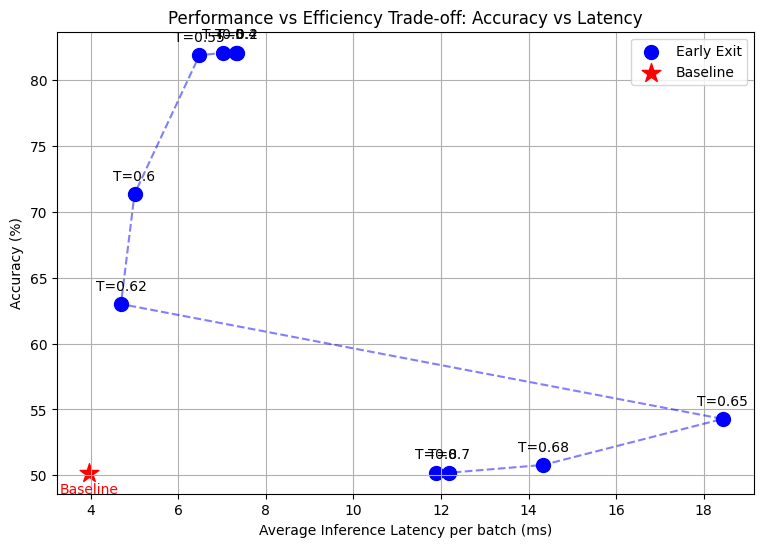

In [ ]:
import matplotlib.pyplot as plt

threshold_values = [0.2, 0.55, 0.6, 0.62, 0.65, 0.68, 0.7, 0.8]
accuracies = []
latencies = []

print("Evaluating diverse confidence thresholds...")
for t in threshold_values:
    early_exit_model.set_threshold(t)
    acc = eval_accuracy(early_exit_model, test_dataloader, device=DEVICE)
    lat, _ = eval_speed(early_exit_model, test_dataloader, device=DEVICE)
    accuracies.append(acc * 100)
    latencies.append(lat)

base_acc = eval_accuracy(early_exit_baseline, test_dataloader, device=DEVICE) * 100
base_lat, _ = eval_speed(early_exit_baseline, test_dataloader, device=DEVICE)

plt.figure(figsize=(9, 6))
plt.scatter(latencies, accuracies, color='b', s=100, label='Early Exit')
plt.plot(latencies, accuracies, 'b--', alpha=0.5)

for i, t in enumerate(threshold_values):
    plt.annotate(f"T={t}", (latencies[i], accuracies[i]), xytext=(0, 10), textcoords="offset points", ha='center')

plt.scatter([base_lat], [base_acc], color='r', marker='*', s=200, label='Baseline')
plt.annotate("Baseline", (base_lat, base_acc), xytext=(0, -15), textcoords="offset points", ha='center', color='red')

plt.title('Performance vs Efficiency Trade-off: Accuracy vs Latency')
plt.xlabel('Average Inference Latency per batch (ms)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("=== Head Finetuning ===")
for head_idx in range(early_exit_model.num_heads):
    early_exit_model.finetune_classifier_head(head_idx, train_dataloader, device=DEVICE)

print("\n=== Optimal Threshold Selection (Latency Budget 4.5ms) ===")
latency_constraint = 4.5
threshold_options = [0.2, 0.55, 0.6, 0.62, 0.65, 0.68, 0.7, 0.8]

for head_idx in range(early_exit_model.num_heads):
    best_acc = 0
    best_threshold = 0.5
    for t in threshold_options:
        early_exit_model.set_threshold(t, head_idx=head_idx)
        acc = eval_accuracy_head(early_exit_model, val_dataloader, device=DEVICE, head_idx=head_idx)
        latency = eval_speed(early_exit_model, val_dataloader, device=DEVICE)[0]
        if acc >= best_acc and latency <= latency_constraint:
            best_acc = acc
            best_threshold = t
    print(f"Head {head_idx} | Optimal threshold: {best_threshold} | Acc: {best_acc:.4f}")
    early_exit_model.set_threshold(best_threshold, head_idx=head_idx)

print("\n=== Final Evaluation After Finetuning ===")
early_exit_model.eval()
eval_accuracy(early_exit_model, test_dataloader, device=DEVICE)
eval_speed(early_exit_model, test_dataloader, device=DEVICE)



Finetuning head 0...


Finetuning head 0: 100%|██████████| 391/391 [00:09<00:00, 39.23it/s]



Finetuning head 1...


Finetuning head 1: 100%|██████████| 391/391 [00:10<00:00, 38.16it/s]



Selecting threshold for head 0...


...

Head 0 Accuracy: 49.89% (6236/12500)
6400 samples in 0.3939s
Throughput:      16248.7 samples/sec
Avg batch:       3.94 ms
Avg per-sample:  0.06 ms


Eval Accuracy Head 0: 100%|██████████| 196/196 [00:05<00:00, 35.46it/s]


Head 0 Accuracy: 49.89% (6236/12500)
6400 samples in 0.4044s
Throughput:      15825.8 samples/sec
Avg batch:       4.04 ms
Avg per-sample:  0.06 ms


Eval Accuracy Head 0: 100%|██████████| 196/196 [00:05<00:00, 36.08it/s]


Head 0 Accuracy: 49.89% (6236/12500)


Evaluating different confidence thresholds...

--- Threshold: 0.5 ---


Eval Accuracy: 100%|██████████| 196/196 [00:06<00:00, 32.46it/s]


Accuracy: 82.14% (10267/12500)
6400 samples in 0.7274s
Throughput:      8798.0 samples/sec
Avg batch:       7.27 ms
Avg per-sample:  0.11 ms

--- Threshold: 0.65 ---


Eval Accuracy: 100%|██████████| 196/196 [00:05<00:00, 33.14it/s]


Accuracy: 82.15% (10269/12500)
6400 samples in 0.6571s
Throughput:      9740.3 samples/sec
Avg batch:       6.57 ms
Avg per-sample:  0.10 ms

--- Threshold: 0.7 ---


...

Accuracy: 78.74% (9843/12500)
6400 samples in 0.3930s
Throughput:      16283.2 samples/sec
Avg batch:       3.93 ms
Avg per-sample:  0.06 ms

--- Threshold: 0.9 ---


Eval Accuracy: 100%|██████████| 196/196 [00:05<00:00, 36.27it/s]


Accuracy: 78.74% (9843/12500)
6400 samples in 0.3936s
Throughput:      16261.0 samples/sec
Avg batch:       3.94 ms
Avg per-sample:  0.06 ms

--- Baseline Model ---


Eval Accuracy: 100%|██████████| 196/196 [00:06<00:00, 31.50it/s]


Accuracy: 82.10% (10262/12500)
6400 samples in 0.8156s
Throughput:      7847.0 samples/sec
Avg batch:       8.16 ms
Avg per-sample:  0.13 ms


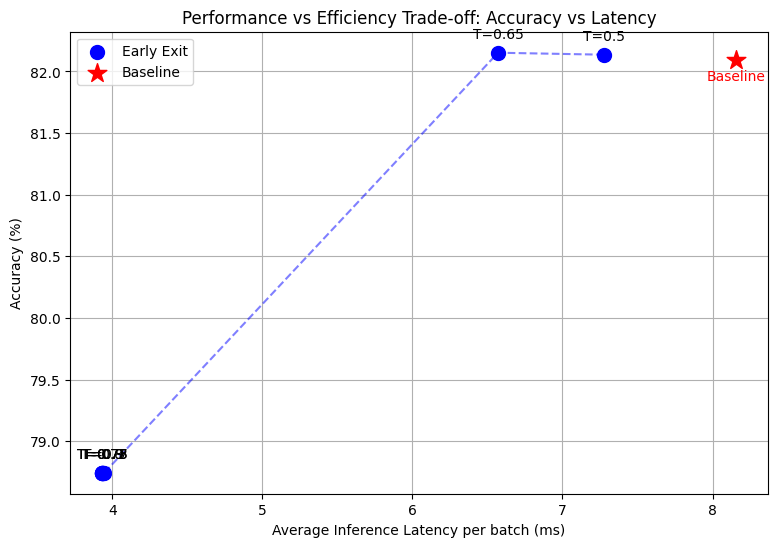

In [ ]:
import matplotlib.pyplot as plt

thresholds = [0.5, 0.65, 0.7, 0.73, 0.75, 0.77, 0.8, 0.9]
accuracies = []
latencies = []

print("Evaluating different confidence thresholds...")
for t in thresholds:
    print(f"\n--- Threshold: {t} ---")
    early_exit_model.set_threshold(t)
    acc = eval_accuracy(early_exit_model, test_dataloader, device=DEVICE)
    lat, _ = eval_speed(early_exit_model, test_dataloader, device=DEVICE)
    accuracies.append(acc * 100)
    latencies.append(lat)

# Get baseline for comparison
print(f"\n--- Baseline Model ---")
base_acc = eval_accuracy(baseline_model, test_dataloader, device=DEVICE) * 100
base_lat, _ = eval_speed(baseline_model, test_dataloader, device=DEVICE)

# Simplified Plotting
plt.figure(figsize=(9, 6))

# Plot Early Exit points
plt.scatter(latencies, accuracies, color='b', s=100, label='Early Exit')
plt.plot(latencies, accuracies, 'b--', alpha=0.5)

for i, t in enumerate(thresholds):
    plt.annotate(f"T={t}", (latencies[i], accuracies[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center')

# Plot Baseline
plt.scatter([base_lat], [base_acc], color='r', marker='*', s=200, label='Baseline')
plt.annotate("Baseline", (base_lat, base_acc), 
             textcoords="offset points", xytext=(0, -15), ha='center', color='red')

plt.title('Performance vs Efficiency Trade-off: Accuracy vs Latency')
plt.xlabel('Average Inference Latency per batch (ms)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()